In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pyart
from les_functions import cartopy_gl_map, find_radar_files, get_composite_radar, model_loc_of_station


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



## Goal: Find Scaling Value for Morrison's Hot Reflectivity

Method: use "rainrate" (or precipitation rate) for a point of continuous precipitation and find an integer mapping
Morrison's reflectivity to Thompson's. 

### Final Result: 
$dBZ_{Thompson} = 0.82(dBZ_{Morrison}) - 3.5$

In [2]:
# Using December case because that contained the most windows of opportunity
case = '2022nov'

casedict = {'2022dec':[pd.to_datetime('2022-12-24 04:00:00'),pd.to_datetime('2022-12-24 10:00:00')],
            '2022jan':[pd.to_datetime('2022-01-19 14:00:00'),pd.to_datetime('2022-01-19 20:00:00')],
            '2022nov':[pd.to_datetime('2022-11-19 12:00:00'),pd.to_datetime('2022-11-19 18:00:00')],}

# Concatenate WRF Reflectivity Files
run_dir  = 'thom_ruc'
for run_dir in ['thom_ruc','morr_ruc']:
    filelist = sorted(glob.glob(f'/nfs/turbo/seas-hutsona/les_wrf_runs/{case}/{run_dir}/wrfout_d01_2022*'))

    sdate,edate = casedict[case][0],casedict[case][1]

    flag = False
    for f,file in enumerate(filelist):
        strs     = file.split('/')[-1].split('_')[-2:]
        filetime = pd.to_datetime(f'{strs[0]} {strs[1]}')
        if (filetime<sdate)|(filetime>edate):
            continue
        print(file)

        fh      = xr.open_dataset(file)
        wtime   = fh.XTIME.data
        if flag is False:
            lat,lon = fh.XLAT.data[0],fh.XLONG.data[0]
        dbz    = fh.REFL_10CM.data[:,0,:,:]
        precip = fh.RAINNC.data[:,:,:]
        dbz[dbz<-10] = np.nan
        dbz    = np.moveaxis(dbz,0,-1)
        precip = np.moveaxis(precip,0,-1)
        if flag is False:
            dbzs = dbz
            precips = precip
            flag = True
        else:
            dbzs = np.dstack((dbzs,dbz))
            precips = np.dstack((precips,precip))
    if run_dir=='thom_ruc':
        print('saving Thompson')
        dbz_t    = dbzs
        precip_t = precips
    if run_dir=='morr_ruc':
        print('saving Morrison')
        dbz_m    = dbzs
        precip_m = precips

/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_12:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_13:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_14:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_15:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_16:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_17:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/thom_ruc/wrfout_d01_2022-11-19_18:00:00
saving Thompson
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/morr_ruc/wrfout_d01_2022-11-19_12:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/morr_ruc/wrfout_d01_2022-11-19_13:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/morr_ruc/wrfout_d01_2022-11-19_14:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/morr_ruc/wrfout_d01_2022-11-19_15:00:00
/nfs/turbo/seas-hutsona/les_wrf_runs/2022nov/morr

In [3]:
rr_t = np.zeros_like(precip_t)
rr_t[:,:,1:] = precip_t[:,:,1:]-precip_t[:,:,:-1]
rr_t[:,:,0] = np.nan

rr_m = np.zeros_like(precip_m)
rr_m[:,:,1:] = precip_m[:,:,1:]-precip_m[:,:,:-1]
rr_m[:,:,0] = np.nan

Text(0.5, 1.0, 'Scaled: $dBZ_{Thompson} = 0.82*dBZ_{Morrison}-3.5$')

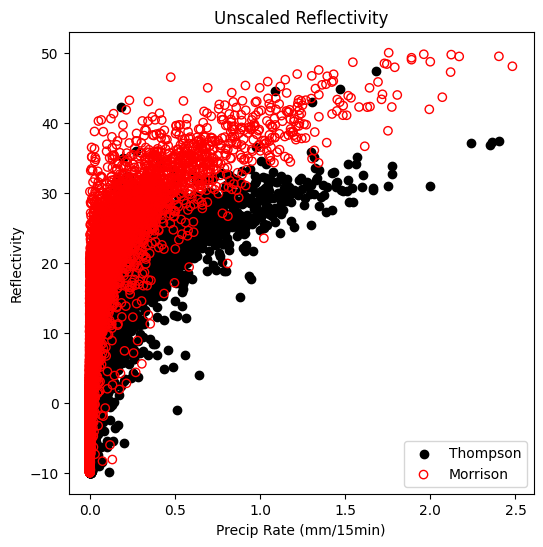

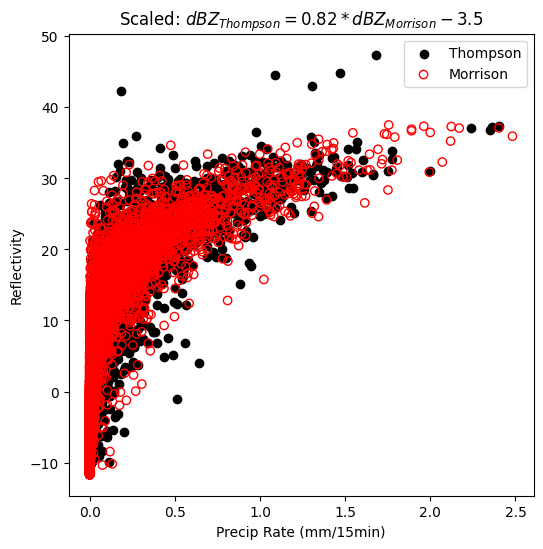

In [9]:
fig = plt.figure(figsize=(6,6))
plt.scatter(rr_t[::10,::10,:],dbz_t[::10,::10,:],color='k',label='Thompson')
plt.scatter(rr_m[::10,::10,:],dbz_m[::10,::10,:],facecolors='none',edgecolors='r',label='Morrison')
plt.xlabel('Precip Rate (mm/15min)')
plt.ylabel('Reflectivity')
plt.legend(loc='best')
plt.title('Unscaled Reflectivity')

# thom = 0.7882175445556641*morr + -5.0839667320251465<-- from January case
# thom = 0.8187727332115173*morr + -2.9496772289276123<-- great match from November case
# thom = 0.8218609690666199*morr + -4.005988121032715 <-- from December case

fig = plt.figure(figsize=(6,6))
plt.scatter(rr_t[::10,::10,:],dbz_t[::10,::10,:],color='k',label='Thompson')
plt.scatter(rr_m[::10,::10,:],(0.82*dbz_m[::10,::10,:])+-3.5,facecolors='none',edgecolors='r',label='Morrison')
plt.xlabel('Precip Rate (mm/15min)')
plt.ylabel('Reflectivity')
plt.legend(loc='best')
plt.title('Scaled: $dBZ_{Thompson} = 0.82*dBZ_{Morrison}-3.5$')

In [32]:
# Bin the reflectivity data based on rain rate
rr_bins = np.arange(0,2.25,0.25)

dig_t = np.digitize(rr_t, rr_bins)
dig_m = np.digitize(rr_m, rr_bins)

# find the mean reflectivity per bin
mean_ref_t,mean_ref_m = [],[]
for r,rr in enumerate(rr_bins):
    mean_ref_t.append(np.nanmean(dbz_t[dig_t==r]))
    mean_ref_m.append(np.nanmean(dbz_m[dig_m==r]))

# Now find mapping integer based on the mean reflectivity per bin
scale = np.array(mean_ref_t)/np.array(mean_ref_m)

/tmp/ipykernel_406935/3208158522.py:10: RuntimeWarning: Mean of empty slice
  mean_ref_t.append(np.nanmean(dbz_t[dig_t==r]))
/tmp/ipykernel_406935/3208158522.py:11: RuntimeWarning: Mean of empty slice
  mean_ref_m.append(np.nanmean(dbz_m[dig_m==r]))


thom = 0.8187727332115173*morr + -2.9496772289276123


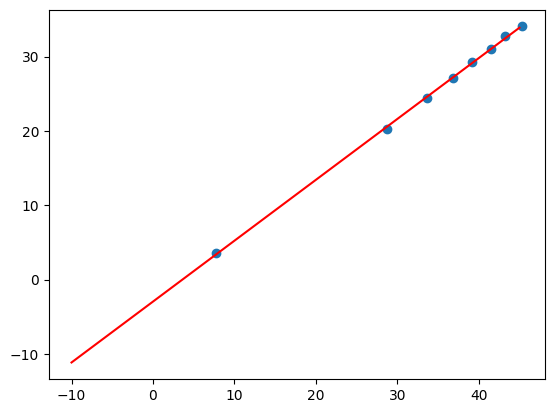

In [33]:
from numpy.polynomial.polynomial import polyfit
idx = np.isfinite(mean_ref_t) & np.isfinite(mean_ref_m)
b, m = polyfit(np.array(mean_ref_m)[idx], np.array(mean_ref_t)[idx], 1)
print(f'thom = {m}*morr + {b}')

plt.scatter(mean_ref_m,mean_ref_t)
plt.plot(np.arange(-10,50,5), b + m * np.arange(-10,50,5), '-',c='r')

In [90]:
np.array(mean_ref_t)[idx]

array([ 7.184658, 19.40228 , 23.372791, 25.92682 , 28.2977  , 29.978697],
      dtype=float32)